# Configure Aggregate Module Params

This notebook should be used as a test for ensuring correct aggregate parameters before aggregate processing.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for aggregate module

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "config/config.yml"

In [2]:
from pathlib import Path
from itertools import product
import random

import yaml
import pandas as pd
import matplotlib.pyplot as plt

from lib.shared.file_utils import get_filename, load_parquet_subset
from lib.aggregate.cell_data_utils import split_cell_data, channel_combo_subset, compartment_subset
from lib.aggregate.cell_classification import CellClassifier
from lib.aggregate.montage_utils import create_cell_montage, add_filenames
from lib.aggregate.filter import (
    query_filter,
    perturbation_filter,
    missing_values_filter,
    intensity_filter,
)
from lib.aggregate.align import (
    prepare_alignment_data,
    pca_variance_plot,
    embed_by_pca,
    tvn_on_controls,
)
from lib.aggregate.aggregate import aggregate
from lib.aggregate.eval_aggregate import (
    nas_summary,
    summarize_cell_data,
    plot_feature_distributions,
)
from lib.shared.configuration_utils import CONFIG_FILE_HEADER
from lib.aggregate.vacuole_utils import aggregate_vacuole_data

random.seed(42)

## <font color='red'>SET PARAMETERS</font>

### Testing on subset of data

- `TEST_PLATE`: Plate used for testing configuration 
- `TEST_WELL_1`: First well identifier used for testing configuration
- `TEST_WELL_2`: Second well identifier used for testing configuration

- `STRATEGY`: Aggregation method for combining vacuole data with cell data

### Aggregation strategies

- `"single"`: Only merge vacuole data for cells with exactly 1 vacuole (`num_vacuoles == 1`). All other cells get NaN values for vacuole columns.
- `"all"`: Create separate columns for each vacuole per cell with numbered suffixes (e.g., `vacuole_area_1`, `vacuole_area_2`).
- `"average"`: Average all numeric vacuole measurements per cell and take the first value for non-numeric columns.
- `None`: Skip aggregation and return only the cells dataframe.

In [10]:
TEST_PLATE = 1
TEST_WELL_1 = "A3"
TEST_WELL_2 = "B2"
AGG_STRATEGY = "none"

In [ ]:
# load config file and determine root path
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)
ROOT_FP = Path(config["all"]["root_fp"])

# Load subset of vacuole data
# Takes ~1 minute
merge_final_fp = (
    ROOT_FP
    / "merge"
    / "parquets"
    / get_filename({"plate": TEST_PLATE, "well": TEST_WELL_1}, "merge_final", "parquet")
)
cell_data = load_parquet_subset(merge_final_fp, n_rows=25000)

merge_final_fp_2 = (
    ROOT_FP
    / "merge"
    / "parquets"
    / get_filename({"plate": TEST_PLATE, "well": TEST_WELL_2}, "merge_final", "parquet")
)
cell_data_2 = load_parquet_subset(merge_final_fp_2, n_rows=5000)

cell_data = pd.concat([cell_data, cell_data_2], ignore_index=True)

if AGG_STRATEGY in ("all", "single", "average"):
    merge_final_fp = (
        ROOT_FP
        / "phenotype"
        / "parquets"
        / get_filename({"plate": TEST_PLATE, "well": TEST_WELL_1}, "phenotype_vacuoles", "parquet")
    )
    vacuole_data = load_parquet_subset(merge_final_fp, n_rows=50000)
    display(vacuole_data)

display(cell_data)

Reading first 25,000 rows from analysis_root/merge/parquets/P-1_W-A3__merge_final.parquet
Reading first 5,000 rows from analysis_root/merge/parquets/P-1_W-B2__merge_final.parquet


,plate,well,site,tile,cell_0,cell_1,global_i_0,global_j_0,global_i_1,global_j_1,...,cytoplasm_second_neighbor_distance,cytoplasm_angle_between_neighbors,cell_area_y,has_vacuole,num_vacuoles,vacuole_ids,total_vacuole_area,vacuole_area_ratio,mean_vacuole_diameter,mean_distance_to_nucleus
0,1,A3,191,2616,14,368,10397.237022,25822.730503,10397.228261,25822.760870,...,197.607809,18.531850,6500,False,0,[],0,0.000000,NaN,NaN
1,1,A3,89,1353,3,278,6580.332070,13132.112296,6580.376623,13132.129870,...,208.105642,135.822991,25700,False,0,[],0,0.000000,NaN,NaN
2,1,A3,216,3258,14,52,12782.133600,1708.769511,12782.141509,1708.707547,...,85.135055,125.799029,16800,True,2,"[7, 13]",4425,0.263393,53.064712,80.875237
3,1,A3,251,3675,20,180,14099.156013,10930.733151,14099.176166,10930.803109,...,258.017262,66.321668,44700,False,0,[],0,0.000000,NaN,NaN
4,1,A3,181,2759,11,366,11185.055331,14603.250296,11185.142180,14603.246445,...,305.778433,58.328224,57600,True,1,[10],1404,0.024375,42.280354,60.006822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1,B2,116,1624,15,339,7595.350455,6839.331709,7594.229167,6841.166667,...,230.129018,48.696389,29800,False,0,[],0,0.000000,NaN,NaN
29996,1,B2,252,3670,42,272,14183.857025,9527.126114,14182.575916,9525.397906,...,300.998404,64.990335,42700,False,0,[],0,0.000000,NaN,NaN
29997,1,B2,222,3234,21,16,12653.093678,8693.742221,12651.369668,8692.454976,...,235.197734,61.474314,58100,False,0,[],0,0.000000,NaN,NaN
29998,1,B2,312,4712,40,40,17331.422243,5884.541024,17331.594340,5882.396226,...,877.525689,23.169958,65800,False,0,[],0,0.000000,NaN,NaN


In [11]:
cell_data = aggregate_vacuole_data(cell_data, vacuole_data, AGG_STRATEGY)
cell_data

,plate,well,site,tile,cell_0,cell_1,global_i_0,global_j_0,global_i_1,global_j_1,...,cytoplasm_second_neighbor_distance,cytoplasm_angle_between_neighbors,cell_area_y,has_vacuole,num_vacuoles,vacuole_ids,total_vacuole_area,vacuole_area_ratio,mean_vacuole_diameter,mean_distance_to_nucleus
0,1,A3,191,2616,14,368,10397.237022,25822.730503,10397.228261,25822.760870,...,197.607809,18.531850,6500,False,0,[],0,0.000000,NaN,NaN
1,1,A3,89,1353,3,278,6580.332070,13132.112296,6580.376623,13132.129870,...,208.105642,135.822991,25700,False,0,[],0,0.000000,NaN,NaN
2,1,A3,216,3258,14,52,12782.133600,1708.769511,12782.141509,1708.707547,...,85.135055,125.799029,16800,True,2,"[7, 13]",4425,0.263393,53.064712,80.875237
3,1,A3,251,3675,20,180,14099.156013,10930.733151,14099.176166,10930.803109,...,258.017262,66.321668,44700,False,0,[],0,0.000000,NaN,NaN
4,1,A3,181,2759,11,366,11185.055331,14603.250296,11185.142180,14603.246445,...,305.778433,58.328224,57600,True,1,[10],1404,0.024375,42.280354,60.006822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1,B2,116,1624,15,339,7595.350455,6839.331709,7594.229167,6841.166667,...,230.129018,48.696389,29800,False,0,[],0,0.000000,NaN,NaN
29996,1,B2,252,3670,42,272,14183.857025,9527.126114,14182.575916,9525.397906,...,300.998404,64.990335,42700,False,0,[],0,0.000000,NaN,NaN
29997,1,B2,222,3234,21,16,12653.093678,8693.742221,12651.369668,8692.454976,...,235.197734,61.474314,58100,False,0,[],0,0.000000,NaN,NaN
29998,1,B2,312,4712,40,40,17331.422243,5884.541024,17331.594340,5882.396226,...,877.525689,23.169958,65800,False,0,[],0,0.000000,NaN,NaN


In [54]:
for col in cell_data.columns:
    print(col)

plate
well
site
tile
cell_0
i_0
j_0
cell_1
i_1
j_1
distance
area_0
area_1
stitched_cell_id_0
stitched_cell_id_1
fov_distance_0
fov_distance_1
cell_barcode_0
gene_symbol_0
mapped_single_gene
channels_min
nucleus_i
nucleus_j
nucleus_bounds_0
nucleus_bounds_1
nucleus_bounds_2
nucleus_bounds_3
cell_i
cell_j
cell_bounds_0
cell_bounds_1
cell_bounds_2
cell_bounds_3
cytoplasm_i
cytoplasm_j
cytoplasm_bounds_0
cytoplasm_bounds_1
cytoplasm_bounds_2
cytoplasm_bounds_3
nucleus_DAPI_int
nucleus_ConA_int
nucleus_Stat6_int
nucleus_Mitotracker_int
nucleus_NHS_ester_int
nucleus_Tubulin_int
nucleus_WGA_int
nucleus_cMYC_int
nucleus_CDPK1_int
nucleus_DAPI_mean
nucleus_ConA_mean
nucleus_Stat6_mean
nucleus_Mitotracker_mean
nucleus_NHS_ester_mean
nucleus_Tubulin_mean
nucleus_WGA_mean
nucleus_cMYC_mean
nucleus_CDPK1_mean
nucleus_DAPI_std
nucleus_ConA_std
nucleus_Stat6_std
nucleus_Mitotracker_std
nucleus_NHS_ester_std
nucleus_Tubulin_std
nucleus_WGA_std
nucleus_cMYC_std
nucleus_CDPK1_std
nucleus_DAPI_max
nucleu

In [55]:
unique_barcodes = cell_data.loc[cell_data["gene_symbol_0"].notna(), "cell_barcode_0"].unique()
print(unique_barcodes)


<StringArray>
['TCACCCT', 'CGTGAAG', 'TGAAAGC', 'CCTCAAT', 'TCCCACA', 'CAACGAC', 'TGCCCTA',
 'CTCCGTT', 'TACGGCT', 'CTTTCTC', 'TGCAACT', 'CCAGCTT', 'CTCGACT', 'CGACATA',
 'CGTGGTT', 'CCTTCCT', 'TCTAGCC', 'TCCCGAT', 'CGAAGAT', 'TGGAGAA', 'CCCTATT',
 'TATTCCC', 'TGTTGTC', 'CCATGGA', 'CTAGAAC', 'CTATGTG', 'CCAAACC', 'CGTCCAA',
 'CCCAAGA', 'TACACTC', 'TCTCGGA', 'CACTAAC', 'TCGATGA', 'TCAGGAA', 'CTTACGA',
 'CGATACT', 'CTACAGT', 'TGTCTAC', 'TGATGGT', 'TACGCGA', 'TCGTCAT', 'CATAGCG',
 'TGAACCA', 'TAACCGG', 'CCAACAA', 'CAATCCA', 'CTTTAGG', 'TAGCGTC', 'CTCACAC',
 'CAGAGTT', 'CGGAACA', 'TGGTAAC', 'CCTGATC', 'CAGAAAG', 'TCTGTTG', 'TCATCTG',
 'TGGGTTC', 'CAAACTG', 'TACTGAG', 'CAGTCGT', 'CACGCAT', 'CAAGGGT', 'TAGTGCA',
 'CATGACA', 'TATCAGC', 'CTAAGGC', 'CTTGGAA', 'TAGGTGT', 'CATTCAG', 'TCGGATT',
 'CCAATGT', 'TCCTTGC', 'CAGGCTA', 'CTGCTCT', 'TGGCTCA', 'CGTTTCA', 'CACAGAA',
 'TGCGTAG', 'TAGTAGG', 'CCCGTAA', 'CCACTCA', 'CGCTTAT', 'CTCCTAG', 'CAATTGC',
 'CGAATCG', 'CTACTTC', 'CACCTTA', 'CGTATGC', 'TAGA

## <font color='red'>SET PARAMETERS</font>

### Cell Data Metadata

- `METADATA_COLS_FP`: Path to TSV to store metadata cols.
- `METADATA_COLS`: Columns in cell data with metadata (use output above).

In [56]:
METADATA_COLS_FP = "config/cell_data_metadata_cols.tsv"
METADATA_COLS = [
    "plate",
    "well",
    "tile",
    "cell_0",
    "i_0",
    "j_0",
    "site",
    "cell_1",
    "i_1",
    "j_1",
    "distance",
    "fov_distance_0",
    "fov_distance_1",
    "gene_symbol_0",
    "mapped_single_gene",
    "channels_min",
    "nucleus_i",
    "nucleus_j",
    "nucleus_bounds_0",
    "nucleus_bounds_1",
    "nucleus_bounds_2",
    "nucleus_bounds_3",
    "cell_i",
    "cell_j",
    "cell_bounds_0",
    "cell_bounds_1",
    "cell_bounds_2",
    "cell_bounds_3",
    "cytoplasm_i",
    "cytoplasm_j",
    "cytoplasm_bounds_0",
    "cytoplasm_bounds_1",
    "cytoplasm_bounds_2",
    "cytoplasm_bounds_3",
    "stitched_cell_id_0",
    "stitched_cell_id_1",
    "cell_barcode_0",	
]

# vacuole features - only add if STRATEGY is not None
if AGG_STRATEGY is not None:
    METADATA_COLS.extend([
        "has_vacuole",
        "num_vacuoles",
        "vacuole_ids",
        "vacuole_id",
        "nearest_nucleus_id",
        "overlap_ratio",
        "vacuole_i",
        "vacuole_j",
        "vacuole_bounds_0",
        "vacuole_bounds_1",
        "vacuole_bounds_2",
        "vacuole_bounds_3",
        "vacuole_number_neighbors_1",
        "vacuole_percent_touching_1",
        "vacuole_first_neighbor_distance",
        "vacuole_second_neighbor_distance",
        "vacuole_angle_between_neighbors",
        "vacuole_area_ratio",
        "total_vacuole_area",
    ])

In [57]:
I_COL = "cell_i"
J_COL = "cell_j"

In [58]:
pd.Series(METADATA_COLS).to_csv(METADATA_COLS_FP, index=False, header=False, sep="\t")

metadata, features = split_cell_data(cell_data, METADATA_COLS)
print(metadata.shape, features.shape)

(30000, 56) (30000, 5498)


## <font color='red'>SET PARAMETERS</font>

### Split cells into classes

- `CLASSIFIER_PATH`: Path to pickled Python object that can take a cell data dataframe and output cell classes

### Evaluate splitting

- `COLLAPSE_COLS`: Cell data columns to collapse on when creating a summary of cell counts. This will show the number of cells in each cell class for these particular columns. Ex: `["sgRNA_0", "gene_symbol_0"]`.
- `MONTAGE_CHANNEL`: Channel to use for montage generation. Usually `DAPI`.

**Notes**: 
- We generate cell classes for each of the classes listed in the classifier and an "all" class. So for a classifier that splits by mitotic or interphase the final classes will be `["mitotic", "interphase", "all"]`.
- You must import necessary packages for the classifier in this notebook and add them to `scripts/aggregate/split_datasets.py` as well. Ex `import numpy as np` if the classifier requires `numpy`.

In [59]:
CLASSIFIER_PATH = None
MONTAGE_CHANNEL = "NHS_ester"
COLLAPSE_COLS = ["gene_symbol_0"]

In [60]:
classifier = CellClassifier.load(CLASSIFIER_PATH)

# Classify cells with safety check
if classifier is not None:
    print("Applying cell classification...")
    classified_metadata, classified_features = classifier.classify_cells(metadata, features)
else:
    print("No classifier specified - using all cells as single class")
    classified_metadata, classified_features = metadata, features

# Create config var for cell classes
if 'class' in classified_metadata.columns:
    CELL_CLASSES = list(classified_metadata["class"].unique())
else:
    CELL_CLASSES = []

# Show cell class counts and distribution
if CELL_CLASSES:  # Only show if we have classes
    print("Cell class counts:")
    print(classified_metadata["class"].value_counts())

    print("\nCell class confidences:")
    classified_metadata["confidence"].hist()
else:
    print("No cell classes available")

No classifier specified - using all cells as single class
No cell classes available


In [61]:
cell_classes = CELL_CLASSES + ["all"]

if classifier is not None:
    classified_metadata_copy = classified_metadata.copy(deep=True)
    classified_metadata_copy = add_filenames(classified_metadata_copy, ROOT_FP)

    # Create a dictionary of DataFrames for each cell class
    cell_class_dfs = {
        cell_class: classified_metadata_copy[classified_metadata_copy["class"] == cell_class]
        for cell_class in CELL_CLASSES
    }

    # Define sorting directions and titles
    title_templates = {
        True: "Lowest Confidence {cell_class} Cells - {channel}",
        False: "Highest Confidence {cell_class} Cells - {channel}",
    }

    # Generate montages dynamically
    montages, titles = [], []
    for cell_class, cell_df in cell_class_dfs.items():
        for ascending in [True, False]:
            montage = create_cell_montage(
                cell_data=cell_df,
                channels=config["phenotype"]["channel_names"],
                selection_params={
                    "method": "sorted",
                    "sort_by": "confidence",
                    "ascending": ascending,
                },
            )[MONTAGE_CHANNEL]
            montages.append(montage)
            titles.append(
                title_templates[ascending].format(
                    cell_class=cell_class, channel=MONTAGE_CHANNEL
                )
            )

    # Determine figure size dynamically
    num_rows = len(CELL_CLASSES)
    fig, axes = plt.subplots(num_rows, 2, figsize=(10, 3 * num_rows))

    # Display montages
    for ax, title, montage in zip(axes.flat, titles, montages):
        ax.imshow(montage, cmap="gray")
        ax.set_title(title, fontsize=14)
        ax.axis("off")

    print("Montages of cell classes:")
    plt.tight_layout()
    plt.show()

    print("Split cell data summary:")
    summary_df = summarize_cell_data(classified_metadata, CELL_CLASSES, COLLAPSE_COLS)
    display(summary_df)


## <font color='red'>SET PARAMETERS</font>

### Aggregate by channel combos

- `CHANNEL_COMBOS`: Combinations of channels to aggregate by. This is a list of lists with channel names, ex `[["DAPI", "CENPA"], ["DAPI", "WGA"]]`.
- `AGGREGATE_COMBO_FP`: Location of aggregate combinations dataframe.
- `TEST_CELL_CLASS`: Cell class to configure aggregate params with. Can be any of the cell classes or `all`.
- `TEST_CHANNEL_COMBO`: Channel combo to configure aggregate params with; must be one of the channel combos. Ex `["DAPI", "CENPA"]`.

In [62]:
CHANNEL_COMBOS = [["DAPI", "ConA", "Stat6", "Mitotracker", "NHS_ester", "Tubulin", "WGA", "cMYC", "CDPK1"], ["DAPI", "ConA", "Stat6", "Mitotracker", "NHS_ester", "Tubulin", "WGA", "cMYC"], ["DAPI", "Stat6", "Tubulin", "WGA", "cMYC"]]
COMPARTMENT_COMBOS = ["cell", "nucleus"]
AGGREGATE_COMBO_FP = "config/aggregate_combo.tsv"

TEST_CELL_CLASS = "all"
TEST_CHANNEL_COMBO = ["DAPI", "Tubulin"]
TEST_COMPARTMENT_COMBO = ["cell", "nucleus"]

In [63]:
# determine cell classes and channel combos
channel_combos = ["_".join(combo) for combo in CHANNEL_COMBOS]
compartment_combos = config["aggregate"]["compartment_combos"]

# Load merge wildcard combos
MERGE_COMBO_FP = Path(config["merge"]["merge_combo_fp"])
merge_wildcard_combos = pd.read_csv(MERGE_COMBO_FP, sep="\t")

# Generate aggregate wildcard combos
aggregate_wildcard_combos = pd.DataFrame(
    product(
        merge_wildcard_combos.itertuples(index=False, name=None),
        cell_classes,
        channel_combos,
        compartment_combos,
    ),
    columns=["plate_well", "cell_class", "channel_combo", "compartment_combo"],
)
aggregate_wildcard_combos[["plate", "well"]] = pd.DataFrame(aggregate_wildcard_combos["plate_well"].tolist(), index=aggregate_wildcard_combos.index)
aggregate_wildcard_combos = aggregate_wildcard_combos.drop(columns="plate_well")

# Save aggregate wildcard combos
aggregate_wildcard_combos.to_csv(AGGREGATE_COMBO_FP, sep="\t", index=False)

print("Aggregate wildcard combos:")
aggregate_wildcard_combos

Aggregate wildcard combos:


,cell_class,channel_combo,compartment_combo,plate,well
0,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,cell,1,B2
1,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,nucleus,1,B2
2,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,cell,1,B2
3,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,nucleus,1,B2
4,all,DAPI_Stat6_Tubulin_WGA_cMYC,cell,1,B2
5,all,DAPI_Stat6_Tubulin_WGA_cMYC,nucleus,1,B2
6,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,cell,1,A3
7,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,nucleus,1,A3
8,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,cell,1,A3
9,all,DAPI_ConA_Stat6_Mitotracker_NHS_ester_Tubulin_...,nucleus,1,A3


In [64]:
# subset cell class
if TEST_CELL_CLASS != "all":
    cell_class_mask = classified_metadata["class"] == TEST_CELL_CLASS
    class_metadata = classified_metadata[cell_class_mask]
    class_features = classified_features[cell_class_mask]
else:
    class_metadata = classified_metadata
    class_features = classified_features

# subset features
all_channels = config["phenotype"]["channel_names"]
class_features = channel_combo_subset(class_features, TEST_CHANNEL_COMBO, all_channels)
class_features = compartment_subset(class_features, TEST_COMPARTMENT_COMBO)

# copy metadata and features for later eval
dataset_metadata = class_metadata.copy()
dataset_features = class_features.copy()

# preview metadata and features
display(class_metadata)
display(class_features)

,plate,well,tile,cell_0,i_0,j_0,site,cell_1,i_1,j_1,...,vacuole_bounds_1,vacuole_bounds_2,vacuole_bounds_3,vacuole_number_neighbors_1,vacuole_percent_touching_1,vacuole_first_neighbor_distance,vacuole_second_neighbor_distance,vacuole_angle_between_neighbors,vacuole_area_ratio,total_vacuole_area
0,1,A3,2759,11,11185.055331,14603.250296,181,366,11185.142180,14603.246445,...,1068.0,1207.0,1119.0,0.0,0.000000,246.073179,354.794351,24.394117,0.024375,1404
1,1,A3,3,21,115.826416,13834.513071,4,48,115.987013,13834.597403,...,1868.0,1382.0,1944.0,1.0,0.027586,89.103550,137.558589,137.247205,0.180741,1952
2,1,A3,3777,4,14193.678733,12924.041972,249,263,14193.795031,12923.888199,...,982.0,128.0,1006.0,0.0,0.000000,126.479892,1008.201859,154.384188,0.010338,367
3,1,A3,3777,14,14233.719000,12780.729918,249,298,14233.771739,12780.923913,...,2198.0,478.0,2267.0,0.0,0.000000,406.080955,1285.486573,39.902717,0.180405,3121
4,1,A3,1209,12,6040.037496,17367.884700,93,129,6040.276817,17367.878893,...,1412.0,1260.0,1448.0,0.0,0.000000,182.961389,505.188794,133.589180,0.024417,1089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1,B2,1624,15,7595.350455,6839.331709,116,339,7594.229167,6841.166667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0
29996,1,B2,3670,42,14183.857025,9527.126114,252,272,14182.575916,9525.397906,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0
29997,1,B2,3234,21,12653.093678,8693.742221,222,16,12651.369668,8692.454976,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0
29998,1,B2,4712,40,17331.422243,5884.541024,312,40,17331.594340,5882.396226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0


,nucleus_DAPI_int,nucleus_Tubulin_int,nucleus_DAPI_mean,nucleus_Tubulin_mean,nucleus_DAPI_std,nucleus_Tubulin_std,nucleus_DAPI_max,nucleus_Tubulin_max,nucleus_DAPI_min,nucleus_Tubulin_min,...,cell_zernike_9_3,cell_zernike_9_5,cell_zernike_9_7,cell_zernike_9_9,cell_number_neighbors_1,cell_percent_touching_1,cell_first_neighbor_distance,cell_second_neighbor_distance,cell_angle_between_neighbors,cell_area_y
0,4032422,3187875,432.849077,342.193538,125.859247,175.847461,796,1168,120,110,...,0.061993,0.099974,0.065450,0.013994,3,0.589467,149.547574,287.095406,64.366161,57600
1,2829097,3720303,468.006121,615.434739,157.726394,263.446904,1042,2563,98,108,...,0.029389,0.055740,0.007285,0.008359,3,0.641473,106.491031,109.210106,139.703571,10800
2,2651445,1995174,423.418237,318.616097,108.346461,148.633308,762,1393,152,101,...,0.061749,0.013726,0.019025,0.010820,2,0.546943,178.512626,272.561982,123.150206,35500
3,3485582,1173448,740.825080,249.404463,157.118163,143.284328,1181,737,338,89,...,0.037350,0.021440,0.064757,0.006018,2,0.586592,143.216304,155.617448,66.190854,17300
4,2778739,3312654,411.421232,490.472905,95.647336,152.409223,822,1204,132,211,...,0.028264,0.014462,0.030881,0.013678,3,0.570234,143.902301,221.953405,147.788250,44600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,5201336,3412343,922.222695,605.025355,362.767766,197.506612,1927,1289,163,143,...,0.057193,0.054088,0.039120,0.014247,4,0.661647,207.512574,216.508651,52.660080,29800
29996,3195243,984207,450.987015,138.914185,114.221520,29.846263,811,327,179,85,...,0.118741,0.018281,0.036648,0.066164,2,0.350610,285.020659,287.054308,63.156137,42700
29997,5178492,2133193,576.733712,237.575788,132.465495,81.106886,1137,517,120,107,...,0.049334,0.011650,0.025077,0.014279,3,0.534864,205.277562,228.662730,66.841870,58100
29998,9422463,6506202,869.872877,600.646418,296.417901,188.787802,1961,1604,137,198,...,0.033607,0.016040,0.016275,0.015199,1,0.232784,251.776709,868.037850,21.542078,65800


## <font color='red'>SET PARAMETERS</font>

### Perturbation filtering

- `FILTER_QUERIES`: Queries to use for custom filtering; ex: `["mapped_single_gene == True", "cell_quality_score > 0.8"]`. Can be left as `None` for no filtering.
- `PERTURBATION_NAME_COL`: Name of column used to identify perturbations. This is the column that aggregation takes place on. Ex "gene_symbol_0".

In [65]:
FILTER_QUERIES = ["well == 'A3'", "num_vacuoles == 1", "mapped_single_gene == True"]
PERTURBATION_NAME_COL = "gene_symbol_0"

Query 'well == 'A3'' filtered out 5000 cells
Query 'num_vacuoles == 1' filtered out 21809 cells
Query 'mapped_single_gene == True' filtered out 1797 cells
Found 1394 cells with assigned perturbations
Unique populations: 49


/lab/ops_analysis/lourido/nebo-analysis/brieflow/workflow/lib/aggregate/filter.py:40: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  metadata_filtered = metadata.query(q)


Empty DataFrame
Columns: [column, percent_na]
Index: []


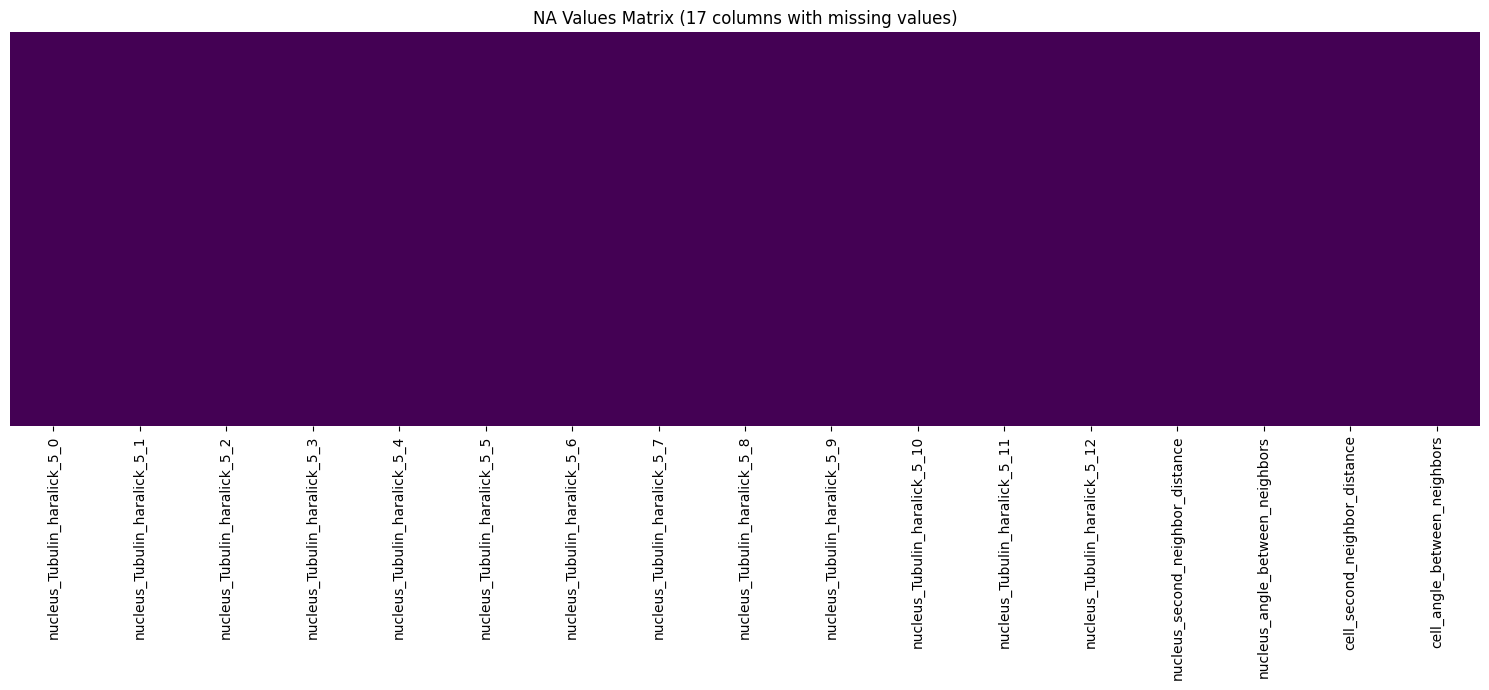

In [66]:
qf_metadata, qf_features = query_filter(class_metadata, class_features, FILTER_QUERIES)

pf_metadata, pf_features = perturbation_filter(
    qf_metadata, qf_features, PERTURBATION_NAME_COL
)
print(f"Unique populations: {metadata[PERTURBATION_NAME_COL].nunique()}")

summary_df, fig = nas_summary(pf_features)
print(summary_df[summary_df["percent_na"] > 0.1])
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Missing value filtering

- `DROP_COLS_THRESHOLD`: Threshold of NA values above which an entire column is dropped. Usually `0.1`
- `DROP_ROWS_THRESHOLD`: Threshold of NA values above which an entire row is dropped. Usually `0.01`
- `IMPUTE`: Whether or not to impute remaining missing values. Usually `True`

**Note**: All NAs must be dropped or imputed to perform feature alignment.

In [67]:
DROP_COLS_THRESHOLD = 0.1
DROP_ROWS_THRESHOLD = 0.1
IMPUTE = True

In [68]:
# Filter by missing values
mvf_metadata, mvf_features = missing_values_filter(
    pf_metadata,
    pf_features,
    drop_cols_threshold=DROP_COLS_THRESHOLD,
    drop_rows_threshold=DROP_ROWS_THRESHOLD,
    impute=True,
)

mvf_metadata.shape, mvf_features.shape

Dropped 0 rows with ≥10.0% missing values
Imputing 17 columns with remaining missing values using batched KNN
Imputing for batch 1 with 2 NA rows


((1394, 56), (1394, 579))

## <font color='red'>SET PARAMETERS</font>

### Intensity filtering

- `CONTAMINATION`: Expected proportion of outliers in dataset. Usually `0.01`

In [69]:
CONTAMINATION = 0.01

In [70]:
# Filter by intensity outliers
if_metadata, if_features = intensity_filter(
    mvf_metadata,
    mvf_features,
    config["phenotype"]["channel_names"],
    CONTAMINATION,
)

if_metadata.shape, if_features.shape

Intensity filtering detected 14 outliers out of 1394 cells


((1380, 56), (1380, 579))

## <font color='red'>SET PARAMETERS</font>

### Prepare alignment data

- `BATCH_COLS`: Which columns of metadata have batch-specific information. Usually `["plate", "well"]`.


In [71]:
BATCH_COLS = ["plate", "well"]

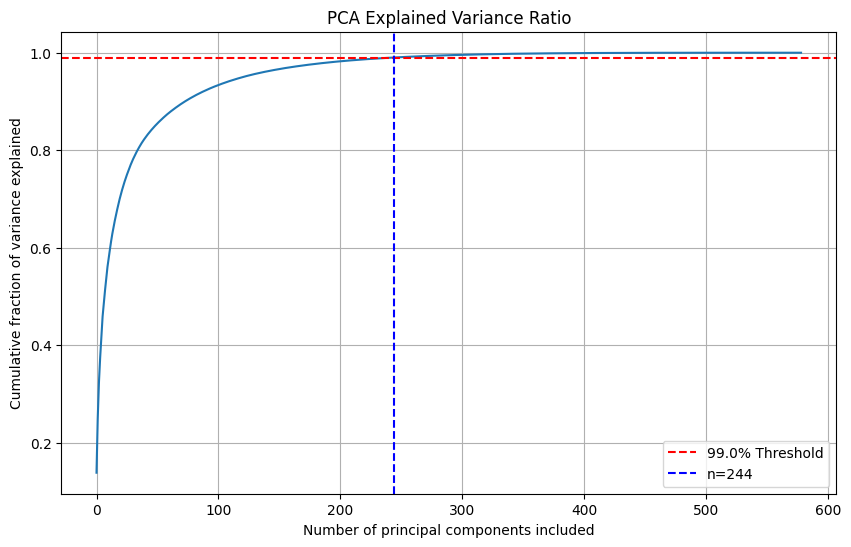

In [72]:
pad_metadata, pad_features = prepare_alignment_data(
    if_metadata, if_features, BATCH_COLS)

n_components, fig = pca_variance_plot(
    pad_features, variance_threshold=0.99
)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Align and aggregate

- `VARIANCE_OR_NCOMP`: Variance or number of components to keep after PCA.
- `NUM_ALIGN_BATCHES`: Number of batches to use when aligning, usually `1`. Increase this if you are running out of memory while aligning. We were able to barely fit 8 plates with 6 wells each in 1 TB of memory with `NUM_ALIGN_BATCHES=1`.
- `AGG_METHOD`: Method used to aggregate features. Can be `mean` or `median`. Usually `median`.
- `CONTROL_KEY`: Name of perturbation in `PERTURBATION_NAME_COL` that indicates a control cell.
- `PERTURBATION_ID_COL`: Name of column that identifies unique perturbations. Only needed if you want your controls to have different perturbation names, ex `sgRNA_0`. Otherwise, can leave this as `None`.

While we use a simplified aggregate method in the notebook, the way this works during a normal run is:
1) Take a subset of 1,000,000 cells, or the entire dataset, whichever is smaller and compute a PCA transform with `VARIANCE_OR_NCOMP`.
2) Subset the entire dataset `NUM_BATCHES` number of times and align cells in this batch.
3) Aggregate across all aligned cell data.

In [73]:
VARIANCE_OR_NCOMP = 150
NUM_ALIGN_BATCHES = 1
AGG_METHOD = "median"
CONTROL_KEY = "nontargeting"
PERTURBATION_ID_COL = "gene_symbol_0"

In [74]:
pca_embeddings = embed_by_pca(
    pad_features, pad_metadata, variance_or_ncomp=VARIANCE_OR_NCOMP, batch_col="batch_values"
)

tvn_normalized = tvn_on_controls(
    pca_embeddings, pad_metadata, PERTURBATION_ID_COL, CONTROL_KEY, "batch_values"
)

aggregated_embeddings, aggregated_metadata = aggregate(
    tvn_normalized, pad_metadata, PERTURBATION_NAME_COL, AGG_METHOD
)

feature_columns = [f"PC_{i}" for i in range(tvn_normalized.shape[1])]

tvn_normalized_df = pd.DataFrame(
    tvn_normalized, index=pad_metadata.index, columns=feature_columns
)
aligned_cell_data = pd.concat([pad_metadata, tvn_normalized_df], axis=1)

aggregated_embeddings_df = pd.DataFrame(
    aggregated_embeddings, index=aggregated_metadata.index, columns=feature_columns
)
aggregated_cell_data = (
    pd.concat([aggregated_metadata, aggregated_embeddings_df], axis=1)
    .sort_values("cell_count", ascending=False)
    .reset_index(drop=True)
)

/lab/ops_analysis/lourido/nebo-analysis/brieflow/workflow/lib/aggregate/align.py:234: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  batch_ind & (metadata[pert_col].str.startswith(control_key)).to_list()
/lab/ops_analysis/lourido/nebo-analysis/brieflow/workflow/lib/aggregate/align.py:164: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  batch_ind & (metadata[pert_col].str.startswith(control_key)).to_list()


/lab/ops_analysis/lourido/nebo-analysis/brieflow/workflow/lib/aggregate/eval_aggregate.py:130: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_orig = df_orig.groupby(["Feature", "plate_well"], group_keys=False).apply(
/lab/ops_analysis/lourido/nebo-analysis/brieflow/workflow/lib/aggregate/eval_aggregate.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aligned = df_aligned.groupby(["Feature", "plate_well"], g

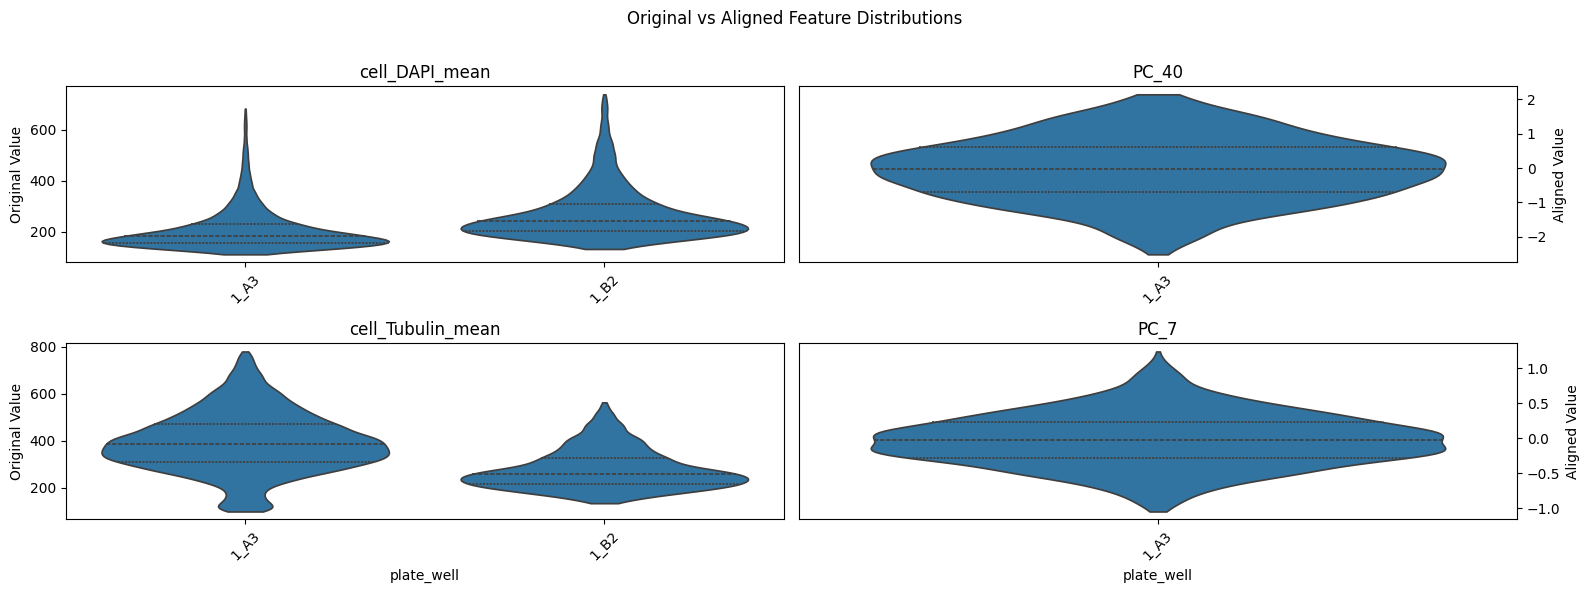

In [75]:
original_feature_cols = [col for col in dataset_features.columns if (f"{COMPARTMENT_COMBOS[0]}_" in col and col.endswith("_mean"))]
pc_cols = [col for col in aggregated_cell_data.columns if col.startswith("PC_")]
aligned_feature_cols = random.sample(pc_cols, k=min(len(original_feature_cols), len(pc_cols)))

original_cell_data = pd.concat([dataset_metadata, dataset_features], axis=1)
original_cell_data

feature_distributions_fig = plot_feature_distributions(
    original_feature_cols,
    original_cell_data,
    aligned_feature_cols,
    aligned_cell_data,
)
plt.show()

## Add aggregate parameters to config file

In [76]:
# Add aggregate section
config["aggregate"] = {
    "agg_strategy": AGG_STRATEGY,
    "metadata_cols_fp": METADATA_COLS_FP,
    "collapse_cols": COLLAPSE_COLS,
    "classifier_path": CLASSIFIER_PATH,
    "cell_classes": CELL_CLASSES,
    "aggregate_combo_fp": AGGREGATE_COMBO_FP,
    "filter_queries": FILTER_QUERIES,
    "perturbation_name_col": PERTURBATION_NAME_COL,
    "drop_cols_threshold": DROP_COLS_THRESHOLD,
    "drop_rows_threshold": DROP_ROWS_THRESHOLD,
    "impute": IMPUTE,
    "contamination": CONTAMINATION,
    "batch_cols": BATCH_COLS,
    "control_key": CONTROL_KEY,
    "perturbation_id_col": PERTURBATION_ID_COL,
    "variance_or_ncomp": VARIANCE_OR_NCOMP,
    "num_align_batches": NUM_ALIGN_BATCHES,
    "agg_method": AGG_METHOD,
    "channel_combos": CHANNEL_COMBOS,
    "compartment_combos": COMPARTMENT_COMBOS,
    "i_col": I_COL,
    "j_col": J_COL,
}

# Write the updated configuration
with open(CONFIG_FILE_PATH, "w") as config_file:
    # Write the introductory comments
    config_file.write(CONFIG_FILE_HEADER)

    # Dump the updated YAML structure, keeping markdown comments for sections
    yaml.dump(config, config_file, default_flow_style=False, sort_keys=False)